# Diana Ruiz Moctezuma
## Reparación de Secuencia de ADN
### ARNet 

## Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import joblib, time, warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score


## Cargar datos

In [2]:
# Serie completa (para entrenar)
df_completa = pd.read_csv('ADN-Completa.csv')
serie_completa = df_completa.iloc[:, 0].values

# Serie esperada (referencia)
df_reparada = pd.read_csv('ADN-Reparada.csv')
serie_esperada = df_reparada.iloc[:, 0].values

# Serie corrupta — leer línea por línea para no perder los huecos vacíos
with open('ADN-Corrupta.csv') as f:
    lineas = f.readlines()

serie_corrupta = []
for linea in lineas[1:]:  # saltar el header
    valor = linea.strip()
    if valor == '':
        serie_corrupta.append(np.nan)
    else:
        serie_corrupta.append(valor)

serie_corrupta = np.array(serie_corrupta, dtype=object)

print('Serie completa:', len(serie_completa), 'nucleotidos')
print('Serie corrupta:', len(serie_corrupta), 'posiciones')
print('Posiciones dañadas:', sum(pd.isna(serie_corrupta)))

Serie completa: 1300 nucleotidos
Serie corrupta: 1300 posiciones
Posiciones dañadas: 291


## Encoding Bostani

In [3]:
# A=1, C=2, G=3, T=4
BOSTANI = {'A': 1, 'C': 2, 'G': 3, 'T': 4}
BOSTANI_INV = {1: 'A', 2: 'C', 3: 'G', 4: 'T'}

# Convertir serie completa a números
num_completa = []
for base in serie_completa:
    num_completa.append(BOSTANI[base])
num_completa = np.array(num_completa, dtype=float)

# Convertir serie corrupta a números (NaN donde está dañada)
num_corrupta = []
for base in serie_corrupta:
    if str(base) == 'nan':
        num_corrupta.append(np.nan)
    else:
        num_corrupta.append(BOSTANI[base])
num_corrupta = np.array(num_corrupta, dtype=float)

# Índices de las posiciones dañadas
damaged_idx = np.where(np.isnan(num_corrupta))[0]

print('Encoding Bostani: A=1  C=2  G=3  T=4')
print('Posiciones dañadas:', len(damaged_idx))
print('Primeras 5:', damaged_idx[:5])

Encoding Bostani: A=1  C=2  G=3  T=4
Posiciones dañadas: 291
Primeras 5: [ 22  24 109 111 126]


## EDA

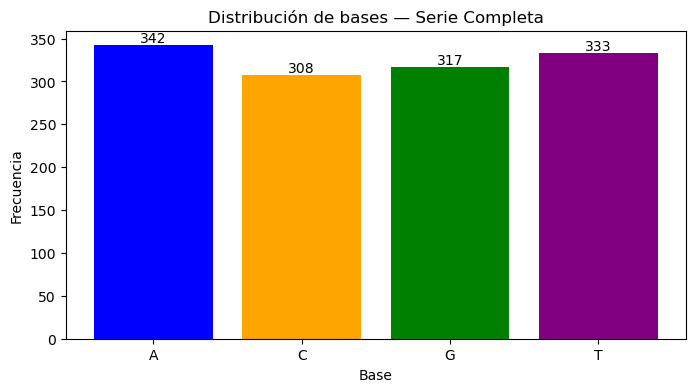

In [4]:
# Contar cuántas veces aparece cada base
bases, conteos = np.unique(serie_completa, return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(bases, conteos, color=['blue', 'orange', 'green', 'purple'])
plt.title('Distribución de bases — Serie Completa')
plt.xlabel('Base')
plt.ylabel('Frecuencia')
for i in range(len(bases)):
    plt.text(i, conteos[i] + 3, str(conteos[i]), ha='center')
plt.savefig('EDA_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()

## Visualizar las series

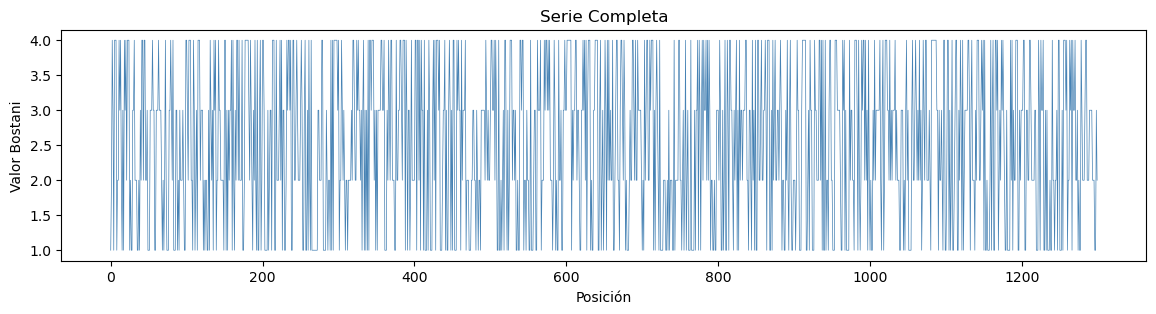

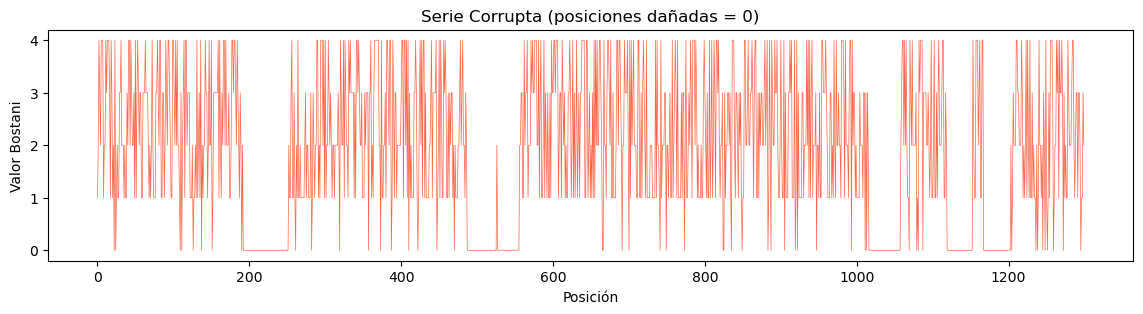

In [5]:
# Serie completa
plt.figure(figsize=(14, 3))
plt.plot(num_completa, linewidth=0.5, color='steelblue')
plt.title('Serie Completa')
plt.xlabel('Posición')
plt.ylabel('Valor Bostani')
plt.savefig('EDA_serie_completa.png', dpi=150, bbox_inches='tight')
plt.show()

# Serie corrupta (reemplazar NaN con 0 solo para graficar)
num_corrupta_plot = np.where(np.isnan(num_corrupta), 0, num_corrupta)

plt.figure(figsize=(14, 3))
plt.plot(num_corrupta_plot, linewidth=0.5, color='tomato')
plt.title('Serie Corrupta (posiciones dañadas = 0)')
plt.xlabel('Posición')
plt.ylabel('Valor Bostani')
plt.savefig('EDA_serie_corrupta.png', dpi=150, bbox_inches='tight')
plt.show()

## Estacionariedad

ADF Estadístico: -31.9956
p-value: 0.0
La serie ES estacionaria


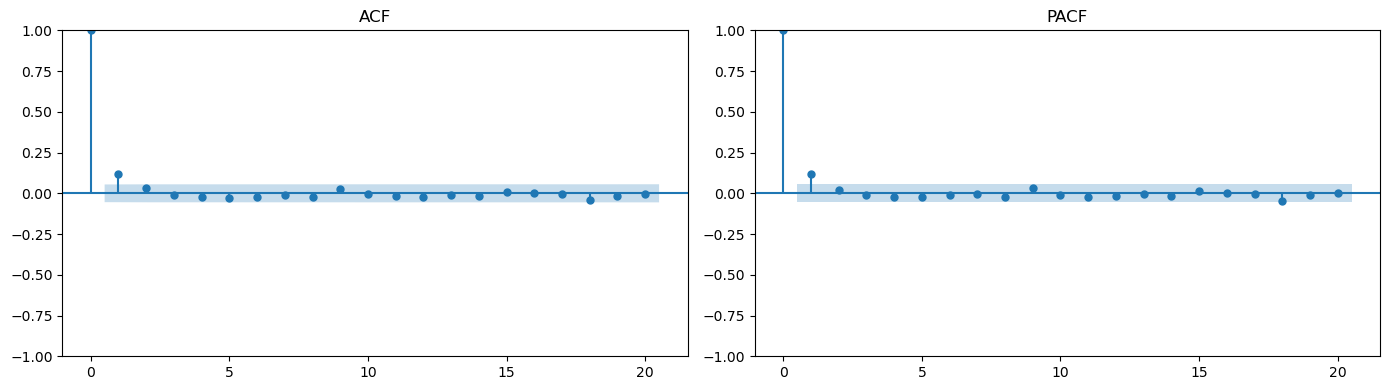

In [6]:
# Test de estacionariedad
resultado = adfuller(num_completa)
print('ADF Estadístico:', round(resultado[0], 4))
print('p-value:', round(resultado[1], 4))
if resultado[1] < 0.05:
    print('La serie ES estacionaria')
else:
    print('La serie NO es estacionaria')

# ACF y PACF
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(num_completa, ax=axes[0], lags=20, title='ACF')
plot_pacf(num_completa, ax=axes[1], lags=20, title='PACF')
plt.tight_layout()
plt.savefig('EDA_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

## Celda 7 — Preparar dataset para ARNet

In [7]:
# Normalizar la serie completa a [0, 1]
scaler = MinMaxScaler()
num_completa_norm = scaler.fit_transform(num_completa.reshape(-1, 1)).flatten()

# input_delays: qué posiciones anteriores usa la red para predecir
input_delays = [1, 2, 3, 4, 5, 6, 7]

# Construir ventanas deslizantes
X = []
y = []

for i in range(max(input_delays), len(num_completa_norm)):
    ventana = [num_completa_norm[i - d] for d in input_delays]
    X.append(ventana)
    y.append(num_completa_norm[i])

X_train = np.array(X)
y_train = np.array(y)

print('input_delays:', input_delays)
print('Muestras de entrenamiento:', len(X_train))
print('Shape X_train:', X_train.shape)

input_delays: [1, 2, 3, 4, 5, 6, 7]
Muestras de entrenamiento: 1293
Shape X_train: (1293, 7)


## Celda 8 — Entrenar ARNet

In [8]:
t0 = time.time()

arnet = MLPRegressor(
    hidden_layer_sizes = (100, 50, 100),
    activation         = 'relu',
    solver             = 'lbfgs',
    alpha              = 0.01,
    learning_rate_init = 1,
    max_iter           = 500,
    random_state       = 666
)

arnet.fit(X_train, y_train)

n_params = sum(w.size for w in arnet.coefs_) + sum(b.size for b in arnet.intercepts_)

print('=== MODELO ARNET ===')
print('hidden_layer_sizes:', arnet.hidden_layer_sizes)
print('activation:', arnet.activation)
print('solver:', arnet.solver)
print('alpha:', arnet.alpha)
print('max_iter:', arnet.max_iter)
print('n_params:', n_params)
print('Tiempo de entrenamiento:', round(time.time() - t0, 4), 's')

=== MODELO ARNET ===
hidden_layer_sizes: (100, 50, 100)
activation: relu
solver: lbfgs
alpha: 0.01
max_iter: 500
n_params: 11051
Tiempo de entrenamiento: 5.5731 s


## Guardar modelo

In [9]:
joblib.dump(arnet,  'modelo_ARNet_ADN.pkl')
joblib.dump(scaler, 'scaler_ARNet_ADN.pkl')

print('Modelo guardado: modelo_ARNet_ADN.pkl')
print('Scaler guardado: scaler_ARNet_ADN.pkl')

# Para cargar despues:
# arnet  = joblib.load('modelo_ARNet_ADN.pkl')
# scaler = joblib.load('scaler_ARNet_ADN.pkl')

Modelo guardado: modelo_ARNet_ADN.pkl
Scaler guardado: scaler_ARNet_ADN.pkl


## Métricas in-sample y out-of-sample

In [10]:
y_pred_train = arnet.predict(X_train)
n = len(y_train)
k = n_params

# Calcular métricas
mse   = mean_squared_error(y_train, y_pred_train)
rmse  = np.sqrt(mse)
smape = np.mean(2 * np.abs(y_pred_train - y_train) / (np.abs(y_pred_train) + np.abs(y_train) + 1e-8)) * 100
r2    = r2_score(y_train, y_pred_train)

residuos = y_train - y_pred_train
ll  = -n/2 * np.log(2 * np.pi * np.var(residuos)) - np.sum(residuos**2) / (2 * np.var(residuos))
aic = 2*k - 2*ll
bic = k * np.log(n) - 2*ll

print('=== METRICAS IN-SAMPLE (ENTRENAMIENTO) ===')
print('MSE_in       :', mse)
print('MSE_in_%     :', mse * 100)
print('RMSE_in      :', rmse)
print('RMSE_in_%    :', rmse * 100)
print('SMAPE_in_%   :', smape)
print('R2_in_Pearson:', r2)
print('AIC_in       :', aic)
print('BIC_in       :', bic)

# Out-of-sample (últimos 20%)
split = int(len(X_train) * 0.8)
X_test = X_train[split:]
y_test = y_train[split:]
y_pred_test = arnet.predict(X_test)
n2 = len(y_test)

mse2   = mean_squared_error(y_test, y_pred_test)
rmse2  = np.sqrt(mse2)
smape2 = np.mean(2 * np.abs(y_pred_test - y_test) / (np.abs(y_pred_test) + np.abs(y_test) + 1e-8)) * 100
r2_2   = r2_score(y_test, y_pred_test)
res2   = y_test - y_pred_test
ll2    = -n2/2 * np.log(2 * np.pi * np.var(res2)) - np.sum(res2**2) / (2 * np.var(res2))
aic2   = 2*k - 2*ll2
bic2   = k * np.log(n2) - 2*ll2

print()
print('=== METRICAS OUT-OF-SAMPLE (PRUEBA) ===')
print('MSE_out       :', mse2)
print('MSE_out_%     :', mse2 * 100)
print('RMSE_out      :', rmse2)
print('RMSE_out_%    :', rmse2 * 100)
print('SMAPE_out_%   :', smape2)
print('R2_out_Pearson:', r2_2)
print('AIC_out       :', aic2)
print('BIC_out       :', bic2)

=== METRICAS IN-SAMPLE (ENTRENAMIENTO) ===
MSE_in       : 0.02267461541620219
MSE_in_%     : 2.267461541620219
RMSE_in      : 0.1505809264688001
RMSE_in_%    : 15.058092646880011
SMAPE_in_%   : 67.39153226024874
R2_in_Pearson: 0.8413479468783318
AIC_in       : 20875.418595535935
BIC_in       : 77950.74350134374

=== METRICAS OUT-OF-SAMPLE (PRUEBA) ===
MSE_out       : 0.021211566661494298
MSE_out_%     : 2.12115666614943
RMSE_out      : 0.145641912447943
RMSE_out_%    : 14.5641912447943
SMAPE_out_%   : 65.5550334848407
R2_out_Pearson: 0.8504875784689524
AIC_out       : 21839.04110897825
BIC_out       : 61145.548018819834


## Análisis de residuales

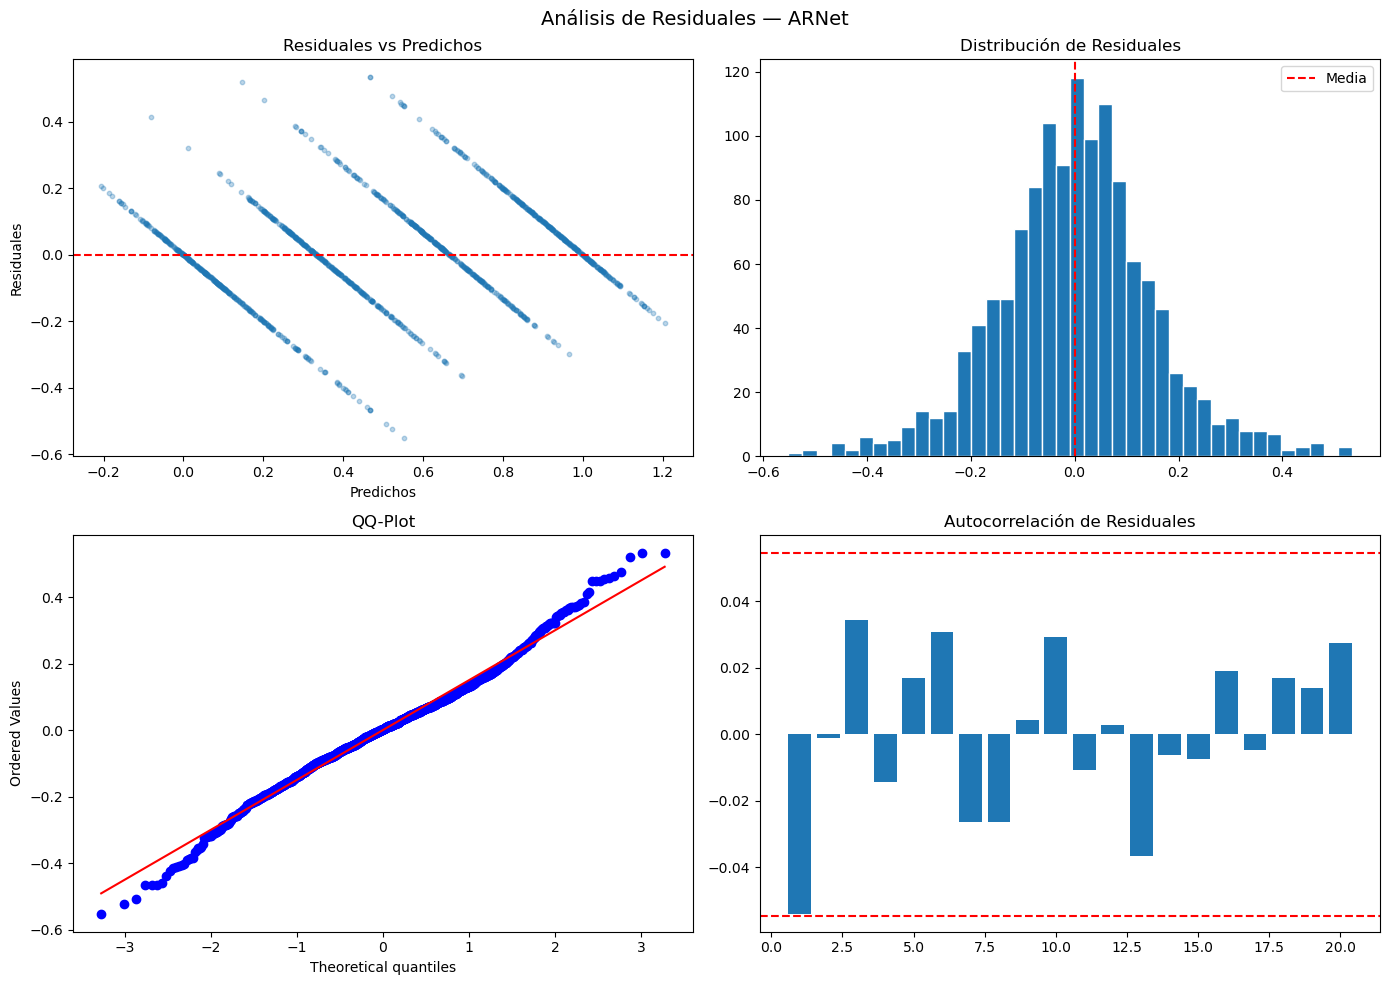

In [11]:
residuos = y_train - y_pred_train

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Análisis de Residuales — ARNet', fontsize=14)

# Residuales vs Predichos
axes[0, 0].scatter(y_pred_train, residuos, alpha=0.3, s=10)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_title('Residuales vs Predichos')
axes[0, 0].set_xlabel('Predichos')
axes[0, 0].set_ylabel('Residuales')

# Distribución de residuales
axes[0, 1].hist(residuos, bins=40, edgecolor='white')
axes[0, 1].axvline(residuos.mean(), color='red', linestyle='--', label='Media')
axes[0, 1].set_title('Distribución de Residuales')
axes[0, 1].legend()

# QQ-Plot
stats.probplot(residuos, dist='norm', plot=axes[1, 0])
axes[1, 0].set_title('QQ-Plot')

# Autocorrelación de residuales
lags_acf = range(1, 21)
acf_vals = [np.corrcoef(residuos[:-l], residuos[l:])[0, 1] for l in lags_acf]
conf = 1.96 / np.sqrt(len(residuos))
axes[1, 1].bar(lags_acf, acf_vals)
axes[1, 1].axhline(conf,  color='red', linestyle='--')
axes[1, 1].axhline(-conf, color='red', linestyle='--')
axes[1, 1].set_title('Autocorrelación de Residuales')

plt.tight_layout()
plt.savefig('ADN_residuales.png', dpi=150, bbox_inches='tight')
plt.show()

## Reparar secuencia corrupta

In [12]:
# Normalizar los valores conocidos de la corrupta
num_corrupta_norm = num_corrupta.copy()
for i in range(len(num_corrupta_norm)):
    if not np.isnan(num_corrupta_norm[i]):
        num_corrupta_norm[i] = scaler.transform([[num_corrupta_norm[i]]])[0][0]

# Reparar posición por posición
serie_reparada = num_corrupta_norm.copy()

for idx in damaged_idx:
    if idx >= max(input_delays):
        ventana = [serie_reparada[idx - d] for d in input_delays]
        if not np.any(np.isnan(ventana)):
            pred = arnet.predict([ventana])[0]
            serie_reparada[idx] = pred
        else:
            # Promedio de vecinos disponibles
            vecinos = []
            for v in serie_reparada[max(0, idx-5) : idx+5]:
                if not np.isnan(v):
                    vecinos.append(v)
            if len(vecinos) > 0:
                serie_reparada[idx] = np.mean(vecinos)
            else:
                serie_reparada[idx] = 0.5
    else:
        serie_reparada[idx] = 0.5

# Desnormalizar y redondear a 1, 2, 3 o 4
serie_reparada = scaler.inverse_transform(serie_reparada.reshape(-1, 1)).flatten()
serie_reparada = np.clip(np.round(serie_reparada), 1, 4)

print('Posiciones reparadas:', len(damaged_idx))
print('NaN restantes:', int(np.sum(np.isnan(serie_reparada))))

Posiciones reparadas: 291
NaN restantes: 0


## Exportar CSV

In [13]:
# Decodificar números a letras
bases_reparadas = []
for valor in serie_reparada:
    bases_reparadas.append(BOSTANI_INV[int(valor)])

bases_reparadas = np.array(bases_reparadas)

# Guardar CSV
df_resultado = pd.DataFrame({'dna_Repaired': bases_reparadas})
df_resultado.to_csv('ADN_reparada_ARNet.csv', index=False)

print('CSV guardado: ADN_reparada_ARNet.csv')
df_resultado.head(10)

CSV guardado: ADN_reparada_ARNet.csv


,dna_Repaired
0,A
1,C
2,T
3,G
4,C
5,T
6,T
7,T
8,A
9,C


## Gráfica final

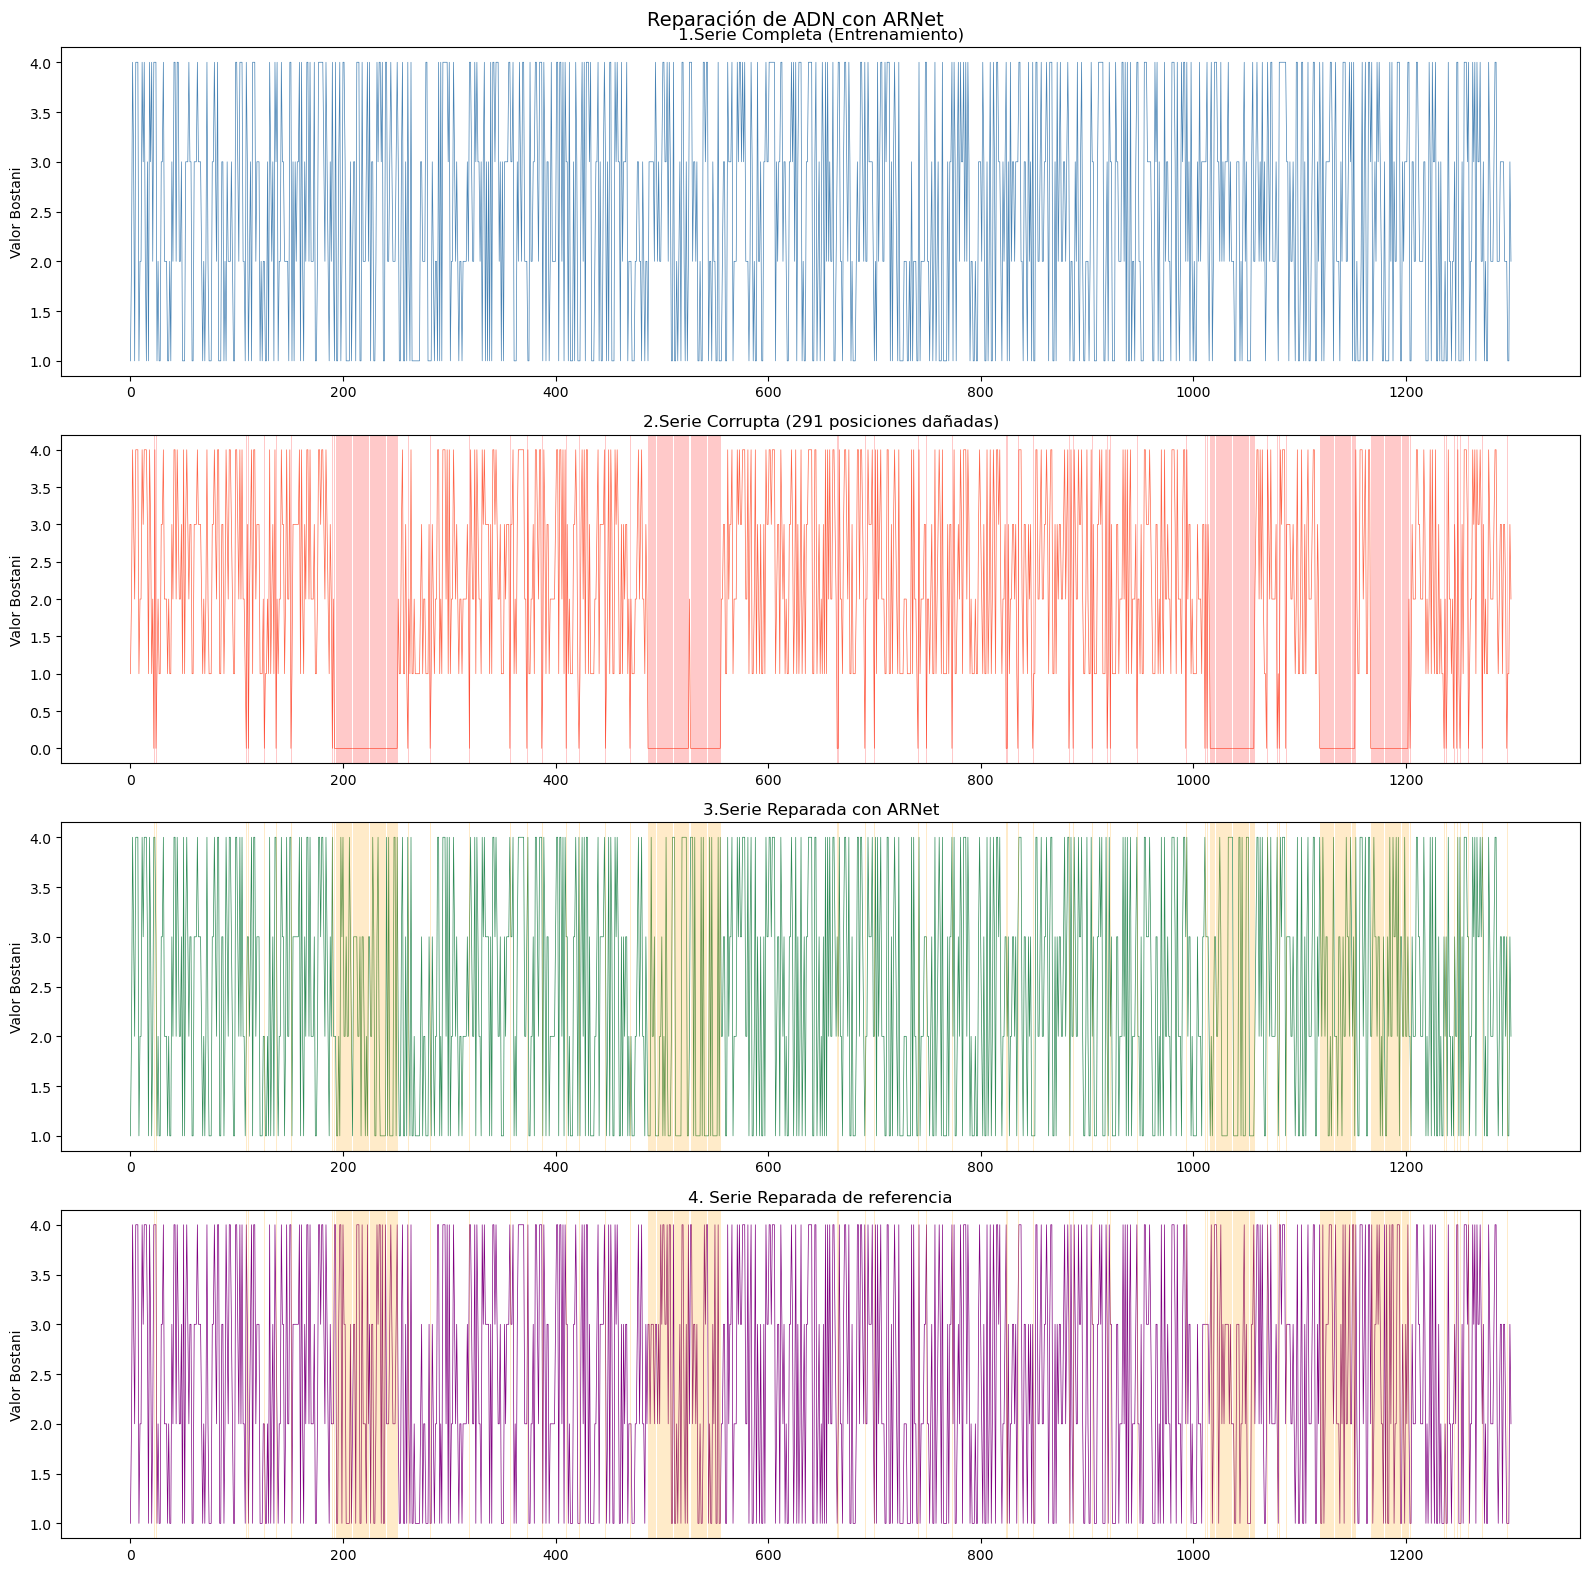

In [14]:

serie_prof = pd.read_csv('ADN-Reparada.csv').iloc[:, 0].values
num_prof   = np.array([BOSTANI[b] for b in serie_prof], dtype=float)

fig, axes = plt.subplots(4, 1, figsize=(16, 16))
fig.suptitle('Reparación de ADN con ARNet', fontsize=14)

# 1. Serie completa
axes[0].plot(num_completa, linewidth=0.5, color='steelblue')
axes[0].set_title('1.Serie Completa (Entrenamiento)')
axes[0].set_ylabel('Valor Bostani')

# 2. Serie corrupta
axes[1].plot(num_corrupta_plot, linewidth=0.5, color='tomato')
for d in damaged_idx:
    axes[1].axvline(x=d, color='red', linewidth=0.5, alpha=0.3)
axes[1].set_title(f'2.Serie Corrupta ({len(damaged_idx)} posiciones dañadas)')
axes[1].set_ylabel('Valor Bostani')

# 3. Serie reparada por ARNet
axes[2].plot(serie_reparada, linewidth=0.5, color='seagreen')
for d in damaged_idx:
    axes[2].axvline(x=d, color='orange', linewidth=0.5, alpha=0.3)
axes[2].set_title('3.Serie Reparada con ARNet')
axes[2].set_ylabel('Valor Bostani')

# 4. Serie reparada 
axes[3].plot(num_prof, linewidth=0.5, color='purple')
for d in damaged_idx:
    axes[3].axvline(x=d, color='orange', linewidth=0.5, alpha=0.3)
axes[3].set_title('4. Serie Reparada de referencia')
axes[3].set_ylabel('Valor Bostani')

plt.tight_layout()
plt.savefig('ADN_comparacion_grafica.png', dpi=150, bbox_inches='tight')
plt.show()